# Logisitic Regression
---




In [187]:
import numpy as np

In [188]:
from sklearn import datasets
iris_dataset = datasets.load_iris()
iris_dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## A) Train/Test Split

<div dir='rtl'>

در این بخش شما باید مجمموعه ی داده را به دو بخش آموزش و ارزیابی  تقسیم کنید. ۸۰ درصد داده‌ها را برای آموزش و باقی را برای ارزیابی بگذارید.
فراموش نکنید که قبل از تقسیم داده آن‌ها را بر بزنید.

</div>

In [189]:
#Set Random Seed
# TODO
np.random.seed(42)

In [190]:
x = iris_dataset.data
y = iris_dataset.target
train_ratio = 0.8

In [191]:
##################
# Train/Test Split
##################
x_train, y_train = None, None
x_test, y_test = None, None
## Your Code Starts Here ##
shuffled_x = np.random.permutation(x)
shuffled_y = np.random.permutation(y)
ones = np.ones(x.shape[0])
shuffled_x = np.c_[ones, shuffled_x]
train_size = int(len(shuffled_x)*train_ratio)
x_train = shuffled_x[:train_size]
y_train = shuffled_y[:train_size]
x_test = shuffled_x[train_size:]
y_test = shuffled_y[train_size:]
## Your Code Ends Here ##

## B) Softmax

<div dir='rtl'>

در این بخش از شما خواسته شده تابع
softmax
را پیاده‌سازی کنید. از این تابع برای محاسبه‌ی احتمال پیش‌بینی شده برای هر کلاس استفاده می‌شود.

$$
softmax(v) = \frac{1}{\sum_{k=1}^{K} e^{v_k}}
\begin{bmatrix}
e^{v_1} \\
e^{v_2} \\
... \\
e^{v_k}
\end{bmatrix}
$$

که در رابطه‌ی بالا
K
تعداد کلاس‌هاست و
$v_k = w_k^Tx$
</div>

In [192]:
##################
# Softmax Function
##################
# X is  (N, d + 1) where d is number of features (one for bias) and n is number of data .
# W is (d + 1, K) where d is number of features (one for bias) and K is number of classes.
def softmax(X, W):
  ## Your Code Starts Here ##
#   preds = []
#   for i in range(X.shape[0]):
#     logits = W.T @ X[i]
#     sample = []
#     every = np.sum(np.exp(logits))
#     for j in logits:
#       sample.append(j/every)
#     preds.append(sample)
#   ## Your Code Ends Here ##
#   preds = []
#   for sample in (X @ W):
#     exp_sample = np.exp(sample)
#     preds.append(exp_sample / np.sum(exp_sample))
    logits = np.exp(X @ W)
    sum_logits = np.sum(logits, axis=1, keepdims=True)
    preds = logits / sum_logits
    ## Your Code Ends Here ##   
    return preds


## C) Predictions

<div dir='rtl'>
  
در این بخش به دنبال پیاده‌سازی تابعی هستیم که با گرفتن احتمال‌های پیش‌بینی شده بازای هر کلاس، کلاسی را که داده‌ به آن تعلق دارد پیش‌بینی کند.

</div>

In [193]:
#####################
# Prediction Function
#####################
# preds: predicted probabilities (N, K)
def return_predicted_classes(preds):
  ## Your Code Starts Here ##
    return np.argmax(np.array(preds), axis=1)
  ## Your Code Ends Here ##


## C) Loss Function

<div dir='rtl'>

در گام بعد با داشتن احتمال تعلق هر داده به هر کلاس از طریق تابع
softmax
به دنبال محاسبه‌ی تابع هزینه هستیم.

$$
loss(X, Y;w) = - \sum_{i=1}^N \sum_{k=1}^K \mathbb{I}[y_i = k]\; log \frac{e^{w_k^Tx}}{\sum_{j=1}^K e^{w_j^Tx}}
$$

</div>

In [194]:
###############
# Loss function
###############
# y: (N)
# preds: class probabilities (N, K)
def logistic_loss(y, preds):
  loss = 0
  ## Your Code Starts Here ##
  for true, pred in zip(y, preds):
    loss -= np.log(pred[true]) / len(y)
  ## Your Code Ends Here ##
  return loss

## D) Weight Updates

<div dir='rtl'>

در این بخش باید رابطه‌ی بروزرسانی وزن‌ها در لاجستیک رگرشن را پیاده‌سازی کنید. این رابطه برای وزن کلاس kام
$w_k$
به صورت زیر است.

$$
w_k \leftarrow w_k - \alpha (\hat{y_i} - y_i) x_i
$$

که در آن
$\alpha$
نرخ یادگیری ،
$\hat{y_i}$
مقدار احتمال پیش‌بینی برای داده‌ی iام
و
$x_i$
داده‌ی iام هستند.

راهنمایی: فراموش نکنید که باید از میانگین گرادیان روی همه‌ی داده‌ها استفاده کنید.

</div>

In [195]:
#####################################
# Implementing weight update function
#####################################
# W: (d+1, K)
# X: (N, d+1)
# y: (N, 1)
# preds: predicted probability for each class (N, K)
# alpha: learning rate
def one_hot_label(x):
    #one hot the labels ranging from 0 to number of classes
    one_hot = np.zeros((x.shape[0], len(np.unique(x))))
    for i, x in enumerate(x):
        one_hot[i][x] = 1
    return one_hot
def update_weights(W, X, y, preds, alpha):
  new_W = None
  ## Your Code Starts Here ##
  oh_y = one_hot_label(y)
  new_W = W - alpha * (X.T @ (preds - oh_y)) / X.shape[0]
  ## Your Code Ends Here ##
  return new_W

## E) Logistic Regression

<div dir='rtl'>

در این بخش شما باید الگوریتم لاجستیگ رگرشن را بوسیله‌ی توابعی که در بخش‌های پیشین پیاده‌سازی کردید، پیاده‌سازی کنید.

دقت کنید که موارد زیر را حتما خروجی دهید:

1. میزان تابع هزینه بازای هر ایپاک بر روی داده‌ی آموزش و تست
2. خروجی نهایی مدل روی داده‌ی آموزش و تست

</div>

In [196]:
##############################
# Logistic Regression Function
##############################
# your output should include:
# 1. train/test losses during training
# 2. final predictions on train/test sets
def logistic_regression(x_train, y_train, x_test, y_test,  n_classes, n_iteration, alpha):
  train_losses, test_losses = [], []
  train_preds, test_preds = [], []
  ## Your Code Starts Here ##
  W = np.random.randn(x_train.shape[1], n_classes)
  for i in range(n_iteration):
    preds = softmax(x_train, W)
    test_pred = softmax(x_test, W)
    W = update_weights(W, x_train, y_train, preds, alpha)
    train_losses.append(logistic_loss(y_train, preds))
    train_preds.append(preds)
    test_pred = softmax(x_test, W)
    test_preds.append(test_pred)
    test_losses.append(logistic_loss(y_test, test_pred))
  ## Your Code Ends Here ##
  return train_losses, test_losses, train_preds, test_preds

In [197]:
##########################
# Run logistic Regression
#########################
# if you implement the code efficiently it should not take more than
# a second to run!
n_classes = 3
#n_iters = 10000
n_iters = 1000

alpha = 0.01

train_losses, test_losses, train_preds, test_preds = logistic_regression(
    x_train,
    y_train,
    x_test,
    y_test,
    n_classes,
    n_iters,
    alpha
)

## F) Plot train/test losses

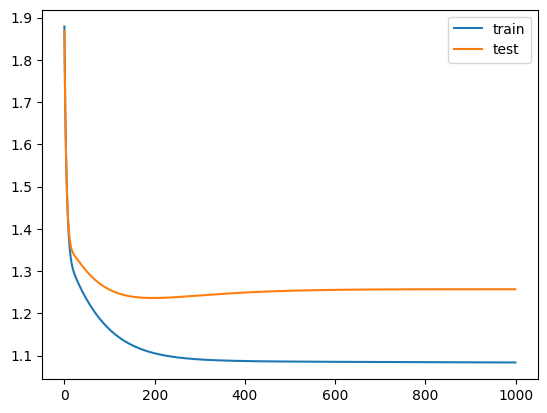

In [198]:
########################
# Plot train/test losses
########################

from matplotlib import pyplot as plt

## Your Code Starts Here ##
plt.plot(range(len(train_losses)), train_losses, label="train")
plt.plot(range(len(test_losses)), test_losses, label="test")
plt.legend()
plt.show()
## Your Code Ends Here ##

## G) Train/Test Accuracy

In [199]:
###########################
# print train/test accuracy
###########################
## Your Code Starts Here ##
return_predicted_classes(train_preds) , y_train
## Your Code Ends Here ##

## Your Code Ends Here ##

(array([[12, 67, 86],
        [12, 67, 86],
        [12, 67, 86],
        ...,
        [ 2, 67, 90],
        [ 2, 67, 90],
        [ 2, 67, 90]], shape=(1000, 3)),
 array([1, 0, 0, 0, 2, 2, 2, 2, 0, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2, 0,
        2, 2, 1, 0, 0, 2, 1, 1, 0, 1, 2, 2, 1, 0, 1, 2, 1, 1, 2, 1, 0, 0,
        2, 0, 0, 0, 2, 2, 1, 1, 0, 1, 0, 0, 0, 2, 0, 1, 1, 1, 1, 0, 2, 2,
        1, 0, 2, 1, 0, 0, 1, 1, 2, 0, 0, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0,
        0, 1, 1, 1, 1, 2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0,
        2, 2, 1, 1, 0, 2, 0, 2, 1, 1]))

In [200]:
x_train

array([[1. , 6.1, 2.8, 4.7, 1.2],
       [1. , 5.7, 3.8, 1.7, 0.3],
       [1. , 7.7, 2.6, 6.9, 2.3],
       [1. , 6. , 2.9, 4.5, 1.5],
       [1. , 6.8, 2.8, 4.8, 1.4],
       [1. , 5.4, 3.4, 1.5, 0.4],
       [1. , 5.6, 2.9, 3.6, 1.3],
       [1. , 6.9, 3.1, 5.1, 2.3],
       [1. , 6.2, 2.2, 4.5, 1.5],
       [1. , 5.8, 2.7, 3.9, 1.2],
       [1. , 6.5, 3.2, 5.1, 2. ],
       [1. , 4.8, 3. , 1.4, 0.1],
       [1. , 5.5, 3.5, 1.3, 0.2],
       [1. , 4.9, 3.1, 1.5, 0.1],
       [1. , 5.1, 3.8, 1.5, 0.3],
       [1. , 6.3, 3.3, 4.7, 1.6],
       [1. , 6.5, 3. , 5.8, 2.2],
       [1. , 5.6, 2.5, 3.9, 1.1],
       [1. , 5.7, 2.8, 4.5, 1.3],
       [1. , 6.4, 2.8, 5.6, 2.2],
       [1. , 4.7, 3.2, 1.6, 0.2],
       [1. , 6.1, 3. , 4.9, 1.8],
       [1. , 5. , 3.4, 1.6, 0.4],
       [1. , 6.4, 2.8, 5.6, 2.1],
       [1. , 7.9, 3.8, 6.4, 2. ],
       [1. , 6.7, 3. , 5.2, 2.3],
       [1. , 6.7, 2.5, 5.8, 1.8],
       [1. , 6.8, 3.2, 5.9, 2.3],
       [1. , 4.8, 3. , 1.4, 0.3],
       [1. , 4

## H) Confusion Matrix

<div dir='rtl'>

در این بخش از شما می‌خواهیم تا ماتریس درهم‌ریختگی را برای پیش‌بینی‌های مدل خود بدست آورید.

</div>

In [201]:
##################
# Confusion Matrix
##################
# preds: predicted classes (N,)
# true: labels (N,)
def get_confusion_matrix(preds, true):
  confusion_matrix = None
  ## Your Code Starts Here ##

  ## Your Code Ends Here ##
  return confusion_matrix

In [202]:
#####################################
# Print Train/Test Confusion Matrices
#####################################
## Your Code Starts Here ##
print(get_confusion_matrix(train_preds, y_train))
print(get_confusion_matrix(test_preds, y_test))

## Your Code Ends Here ##

None
None


## Scikit Learn Version

<div dir='rtl'>


</div>

Define Model

In [219]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression();

Train Model

In [228]:
#TODO
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Predict Tests

In [229]:
# TODO
y_pred = model.predict(x_test)

Print Accuracy

In [230]:
from sklearn.metrics import accuracy_score
# TODO
print(accuracy_score(y_test, y_pred))

0.9333333333333333


Confusion Matrix

In [231]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# TODO
cm = confusion_matrix(y_test, y_pred)


Visual Confusion Matrix

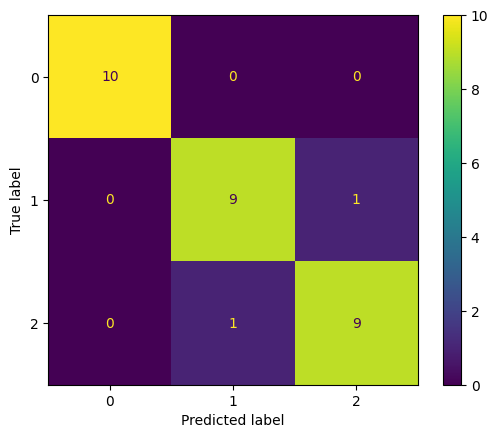

In [232]:
# TODO
disp = ConfusionMatrixDisplay(cm)
disp.plot()

#Perceptron

Reload Dataset

In [225]:
from sklearn import datasets
iris_dataset = datasets.load_iris()
X = iris_dataset.data
y = iris_dataset.target
X.shape, y.shape

((150, 4), (150,))

Use Standard Scaler (OPTIONAL)

In [226]:
#OPTIONAL
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

Split Train Test Using SKlearn

In [227]:
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = None, None, None, None
#TODO
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Get Predicted Class from Logits (Last Layer)

In [212]:
#returns (num_samples, num_class) vector
def get_logits(x, W, b):
  ## TODO
  logit = x @ W + b
  ## END TODO
  return logit

In [213]:
#returns (num_samples,) vector
#returns predicted class for each sample
def get_predict(x, W, b):
  #TODO
  print(x.shape, W.shape, b.shape)
  logits = get_logits(x, W, b)
  pred_prob = softmax(logits, W)
  pred = np.argmax(pred_prob, keepdims=True)
  return pred

In [214]:
def perceptron_train(x_train, y_train, n_classes, n_iteration, alpha):
  ## Your Code Starts Here ##
  
  #define K = number of classes
  #define W = Weights
  #define b = Bias
  #define N = number of samples
  #define D = number of features
  K, N, D = len(np.unique(y_train)), x_train.shape[0], x_train.shape[1]

  W = np.random.randn(D)
  b = np.random.randn(D)
  #TODO

  for t in range(n_iteration):
    for Xi, yi in zip(x_train, y_train):
      pred = get_predict(Xi, W, b)

      if yi != pred:
        #TODO
        W += alpha * Xi * (yi - pred)
        b += alpha * (yi - pred)
  return W, b

In [215]:
##########################
# Run Model
#########################
# if you implement the code efficiently it should not take more than
# a second to run!
n_classes = 3
n_iters = 1000

alpha = 0.01

W, b = perceptron_train(
    X_train,
    y_train,
    n_classes,
    n_iters,
    alpha
)

(4,) (4,) (4,)


AxisError: axis 1 is out of bounds for array of dimension 0

Predict Test Data

In [ ]:
y_hat = None
y_hat

array([1, 2, 2, 2, 2, 1, 1, 2, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 2, 2,
       0, 1, 2, 2, 1, 0, 0, 0])

Accuracy Test

In [ ]:
#TODO

np.float64(0.9333333333333333)

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#TODO

[[ 9  0  0]
 [ 0 11  1]
 [ 0  1  8]]
